In [1]:
!pip install spotipy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install jupyter
!pip install python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.8/409.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 111.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df = pd.read_csv('dataset.csv')

print(df.shape)
print(df.columns.tolist())
print(df.head())

(114000, 21)
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                       

In [6]:
print(df.columns.tolist())


['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


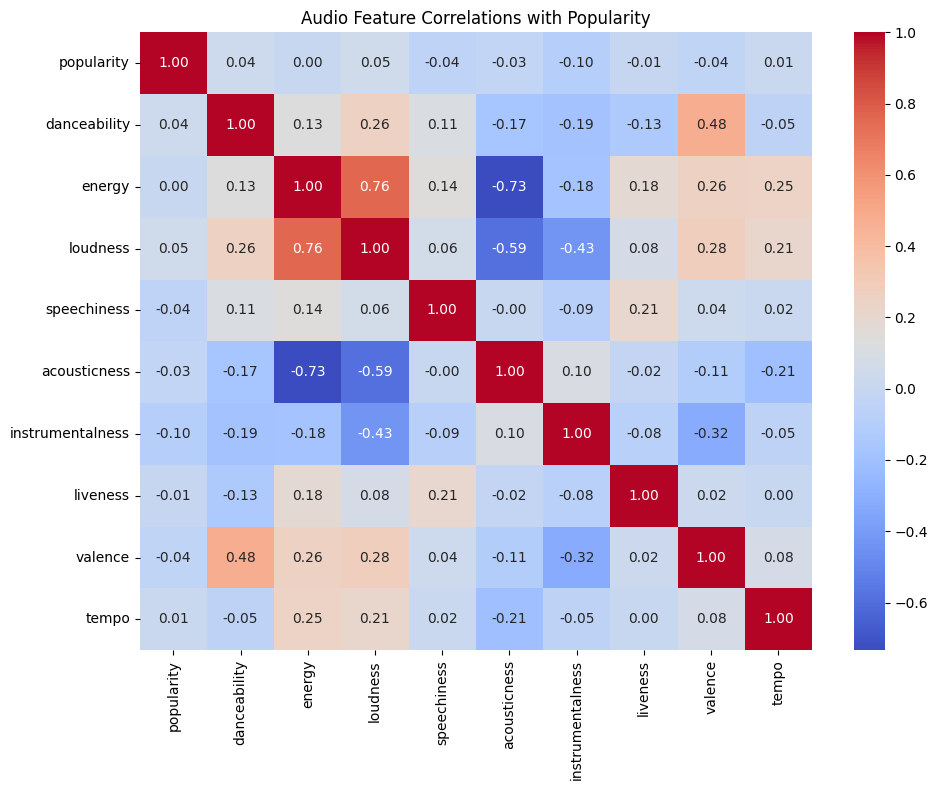

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick the audio features
features = ['popularity', 'danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

# Calculate correlations
corr = df[features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Audio Feature Correlations with Popularity')
plt.tight_layout()
plt.show()

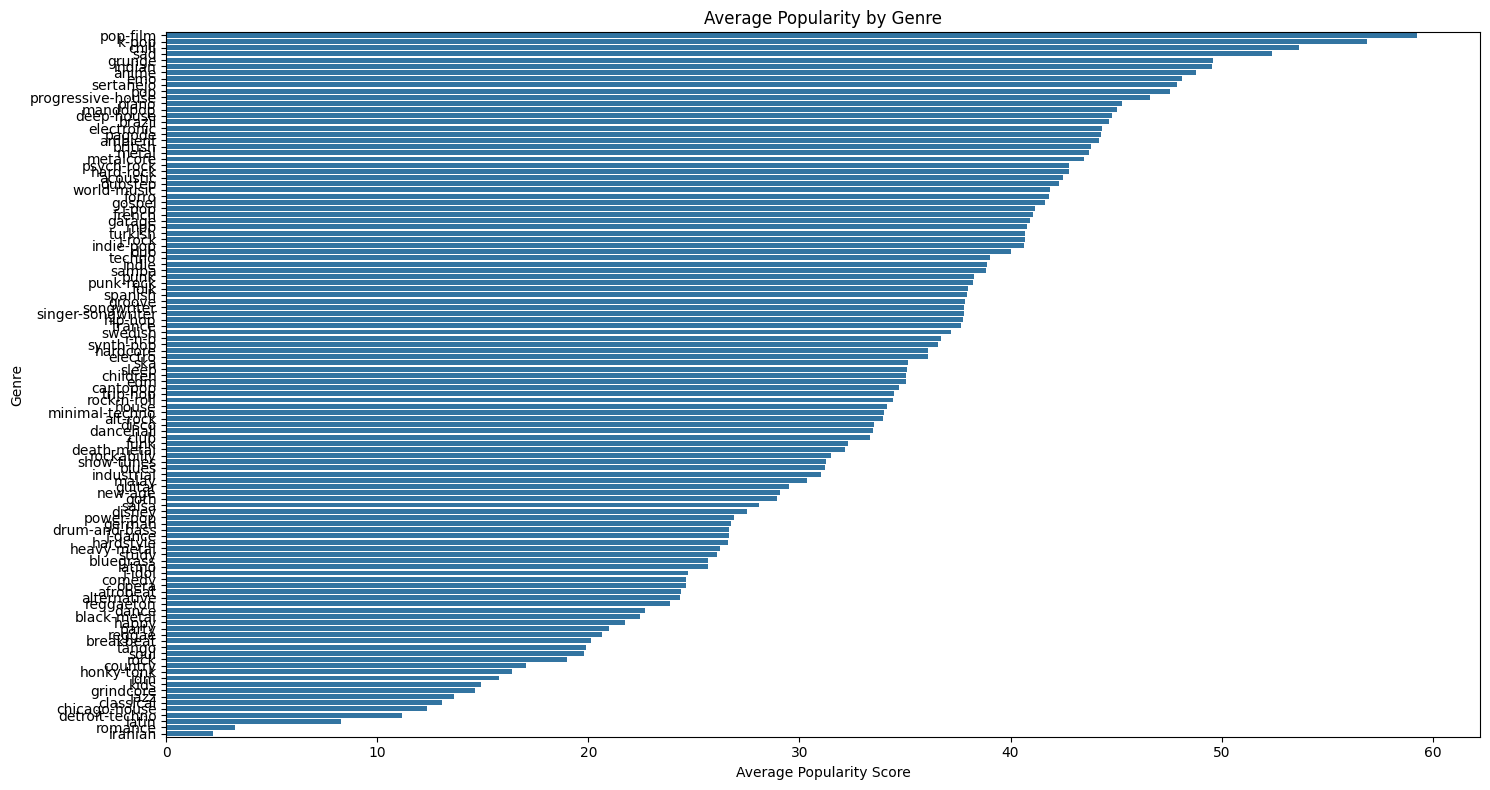

In [8]:
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index)
plt.title('Average Popularity by Genre')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

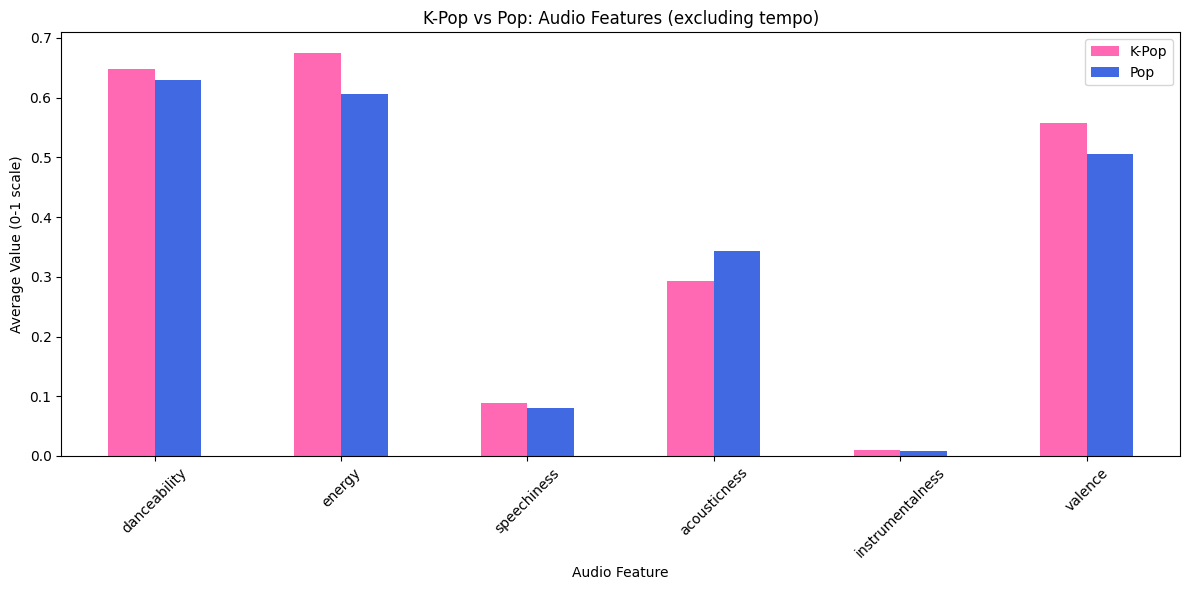

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset.csv')

kpop = df[df['track_genre'] == 'k-pop']
pop = df[df['track_genre'] == 'pop']

features_no_tempo = ['danceability', 'energy', 'speechiness',
                     'acousticness', 'instrumentalness', 'valence']

comparison2 = pd.DataFrame({'K-Pop': kpop[features_no_tempo].mean(),
                            'Pop': pop[features_no_tempo].mean()})

comparison2.plot(kind='bar', figsize=(12, 6), color=['hotpink', 'royalblue'])
plt.title('K-Pop vs Pop: Audio Features (excluding tempo)')
plt.xlabel('Audio Feature')
plt.ylabel('Average Value (0-1 scale)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Finding #1:

No single feature strongly predicts populairty --- the highest correlatio was -0.10 (instrumentalness), which meant popularity can't be explained by sound alone.

Finding #2:

Kpop ranks higher in popularity than regular pop despite similar audi features

Finding #3:

K-pop is more sonically enginerred than regular pop, since it scores higher in danceability, energy, speechiness, instrumentalness & valence, but lower in acousticness. K-pop is deliberately produced to be more intense and upbeat

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Define features and target
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X = df[features].dropna()
y = df.loc[X.index, 'popularity']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")
print(f"This model explains {r2*100:.1f}% of the variation in popularity")

R² Score: 0.0204
This model explains 2.0% of the variation in popularity


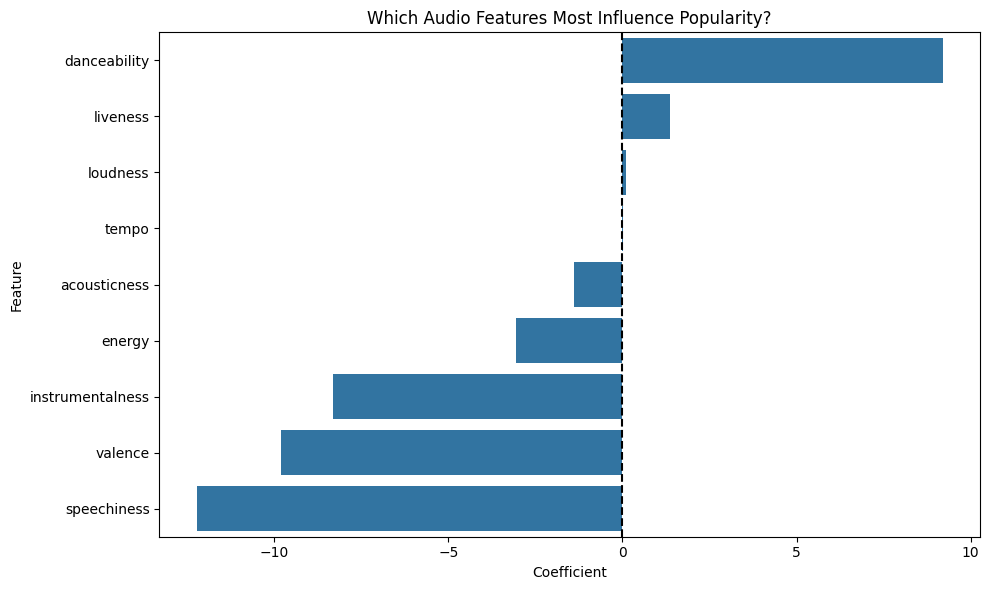

In [12]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature')
plt.title('Which Audio Features Most Influence Popularity?')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

Among all audio features, speechiness, valence, and danceability had the greatest influence on popularity according to the model — suggesting that rhythmic, emotional, and vocal qualities matter more than raw energy or tempo. However, with an R² of only 0.02, even these features explain very little of what drives popularity.



In [11]:
# random forest
from sklearn.ensemble import RandomForestRegressor

# Train random forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test it
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(rf_pred, y_test)
print(f"Random Forest R² Score: {rf_r2:.4f}")
print(f"This model explains {rf_r2*100:.1f}% of the variation in popularity")

# Compare to linear regression
print(f"\nLinear Regression R²: {r2*100:.1f}%")
print(f"Random Forest R²: {rf_r2*100:.1f}%")


Random Forest R² Score: 0.0407
This model explains 4.1% of the variation in popularity

Linear Regression R²: 2.0%
Random Forest R²: 4.1%


/tmp/ipykernel_8079/4256968991.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')


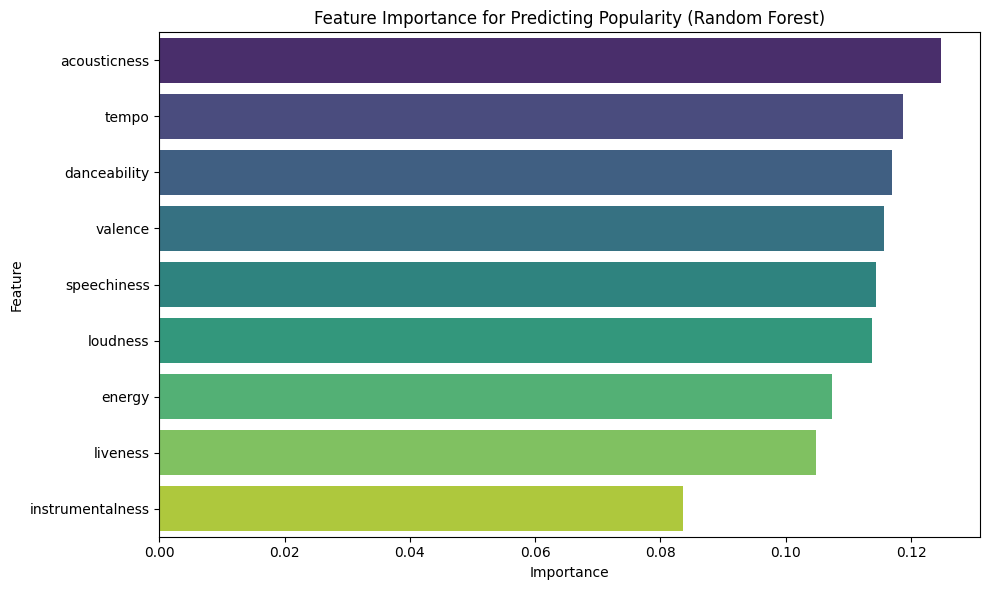

In [14]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Predicting Popularity (Random Forest)')
plt.tight_layout()
plt.show()

In [15]:
top_songs = df[df['popularity'] >= 70]
bottom_songs = df[df['popularity'] <= 20]

print(f"Top songs (70+): {len(top_songs)}")
print(f"Bottom songs (20 and below): {len(bottom_songs)}")

Top songs (70+): 5472
Bottom songs (20 and below): 34177


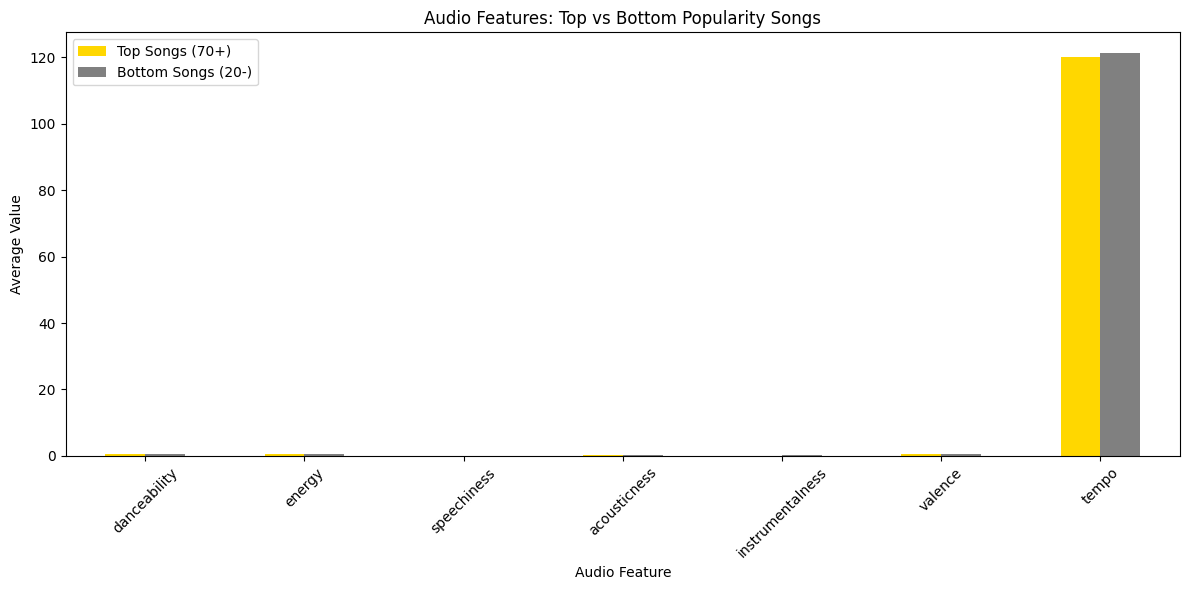

In [16]:
features_to_compare = ['danceability', 'energy', 'speechiness',
                        'acousticness', 'instrumentalness', 'valence', 'tempo']

top_avg = top_songs[features_to_compare].mean()
bottom_avg = bottom_songs[features_to_compare].mean()

comparison = pd.DataFrame({'Top Songs (70+)': top_avg,
                           'Bottom Songs (20-)': bottom_avg})

comparison.plot(kind='bar', figsize=(12, 6), color=['gold', 'gray'])
plt.title('Audio Features: Top vs Bottom Popularity Songs')
plt.xlabel('Audio Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

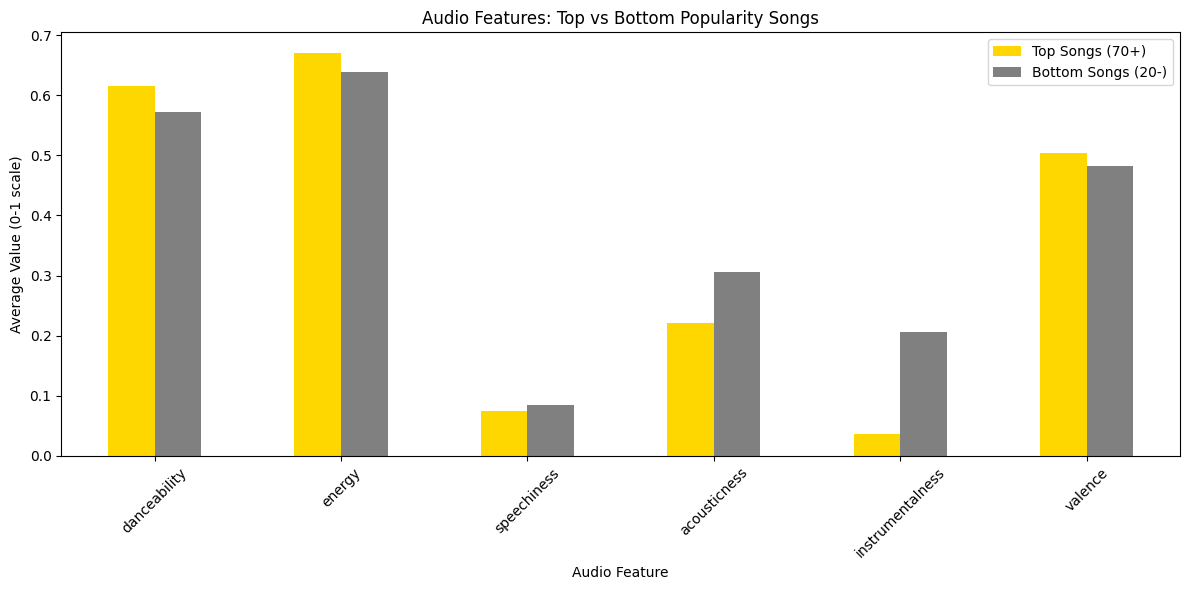

In [17]:
features_0_to_1 = ['danceability', 'energy', 'speechiness',
                    'acousticness', 'instrumentalness', 'valence']

top_avg = top_songs[features_0_to_1].mean()
bottom_avg = bottom_songs[features_0_to_1].mean()

comparison = pd.DataFrame({'Top Songs (70+)': top_avg,
                           'Bottom Songs (20-)': bottom_avg})

comparison.plot(kind='bar', figsize=(12, 6), color=['gold', 'gray'])
plt.title('Audio Features: Top vs Bottom Popularity Songs')
plt.xlabel('Audio Feature')
plt.ylabel('Average Value (0-1 scale)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()